# Análise Comparativa de Desempenho: Ubuntu 26.04.1 vs Kali Linux 2026.2

**Grupo: BAGÉ SYSTEMS**
Eduardo Munhoz Umpierre, Brian, Pedro

Este notebook reproduz, em forma de gráficos, os dados coletados no relatório comparativo entre **Ubuntu 26.04.1** e **Kali Linux 2026.2**, executados em máquinas virtuais equivalentes no VMware Workstation, usando `sysbench` (CPU e memória) e `htop` (consumo em estado ocioso).

> Os dados abaixo foram inseridos manualmente a partir das medições registradas no relatório (execução única por cenário, análise descritiva).

## 1. Configuração inicial

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 110
distros = ["Ubuntu 26.04.1", "Kali Linux 2026.2"]
cores = ["#E95420", "#557C94"]  # laranja Ubuntu, azul Kali

## 2. Dados coletados

Tabela de hardware das VMs: 8 GB RAM, 1 processador virtual (4 núcleos), 20 GB de SSD para ambas as distribuições.

In [2]:
dados = {
    "disco_gb": [8.6, 15.6],
    "ram_idle_gb": [1.04, 0.762],
    "cpu_eventos_s": [1044.93, 1064.46],
    "mem_taxa_mibs": [6371.62, 6487.28],
}
dados

{'disco_gb': [8.6, 15.6],
 'ram_idle_gb': [1.04, 0.762],
 'cpu_eventos_s': [1044.93, 1064.46],
 'mem_taxa_mibs': [6371.62, 6487.28]}

## 3. Espaço em disco e RAM ociosa

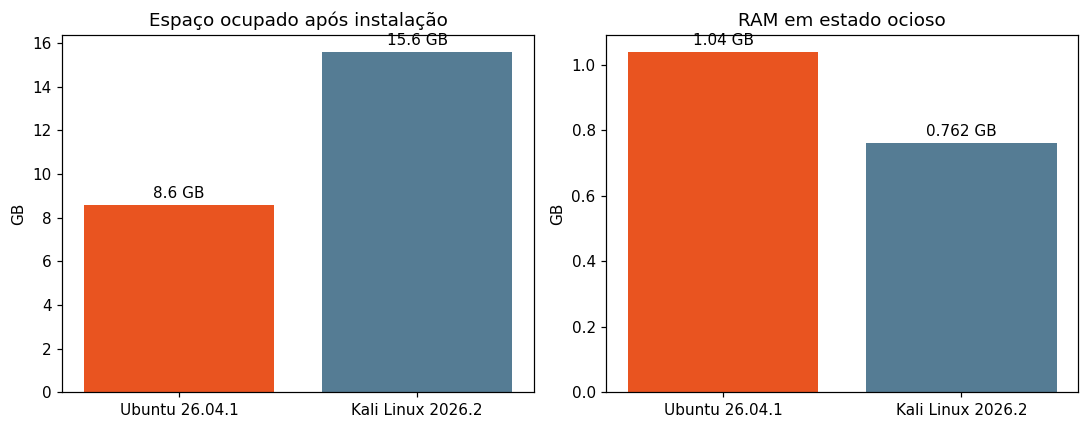

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(distros, dados["disco_gb"], color=cores)
axes[0].set_title("Espaço ocupado após instalação")
axes[0].set_ylabel("GB")
for i, v in enumerate(dados["disco_gb"]):
    axes[0].text(i, v + 0.3, f"{v} GB", ha="center")

axes[1].bar(distros, dados["ram_idle_gb"], color=cores)
axes[1].set_title("RAM em estado ocioso")
axes[1].set_ylabel("GB")
for i, v in enumerate(dados["ram_idle_gb"]):
    axes[1].text(i, v + 0.02, f"{v} GB", ha="center")

plt.tight_layout()
plt.show()

**Observação:** o Kali ocupou cerca de **81,4% a mais** de espaço em disco que o Ubuntu, enquanto consumiu menos RAM em estado ocioso — possivelmente influenciado pelo uso do XFCE (mais leve que o GNOME do Ubuntu).

## 4. Benchmark de CPU (sysbench — 20 mil números primos)

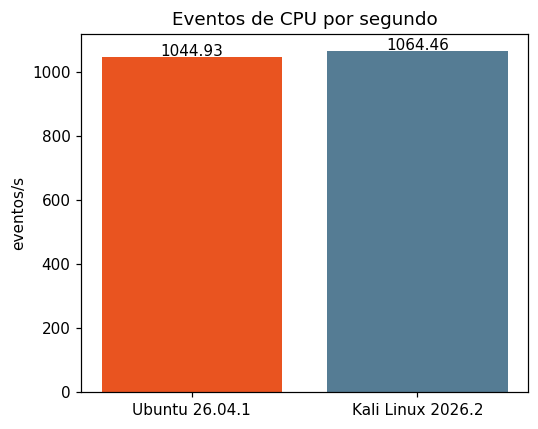

Diferença a favor do Kali: 1.87%


In [4]:
plt.figure(figsize=(5, 4))
plt.bar(distros, dados["cpu_eventos_s"], color=cores)
plt.title("Eventos de CPU por segundo")
plt.ylabel("eventos/s")
for i, v in enumerate(dados["cpu_eventos_s"]):
    plt.text(i, v + 5, f"{v}", ha="center")
plt.tight_layout()
plt.show()

dif_cpu = (dados["cpu_eventos_s"][1] - dados["cpu_eventos_s"][0]) / dados["cpu_eventos_s"][0] * 100
print(f"Diferença a favor do Kali: {dif_cpu:.2f}%")

## 5. Benchmark de memória (sysbench — blocos de 1 KiB até 100 GiB)

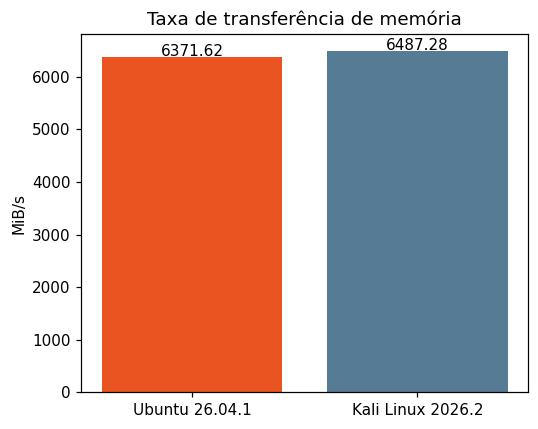

Diferença a favor do Kali: 1.82%


In [5]:
plt.figure(figsize=(5, 4))
plt.bar(distros, dados["mem_taxa_mibs"], color=cores)
plt.title("Taxa de transferência de memória")
plt.ylabel("MiB/s")
for i, v in enumerate(dados["mem_taxa_mibs"]):
    plt.text(i, v + 20, f"{v}", ha="center")
plt.tight_layout()
plt.show()

dif_mem = (dados["mem_taxa_mibs"][1] - dados["mem_taxa_mibs"][0]) / dados["mem_taxa_mibs"][0] * 100
print(f"Diferença a favor do Kali: {dif_mem:.2f}%")

## 6. Conclusão

- O **Kali Linux** apresentou desempenho ligeiramente superior em CPU (~1,87%) e memória (~1,82%), além de menor consumo de RAM ociosa — mas exigiu bem mais espaço em disco.
- O **Ubuntu** teve uma instalação muito mais enxuta em armazenamento, com desempenho praticamente equivalente ao Kali nos testes sintéticos.
- As diferenças de benchmark são pequenas e não substituem uma análise com múltiplas repetições (média, desvio padrão). A escolha entre as distribuições deve considerar principalmente a **finalidade de uso** (uso geral vs segurança da informação), não apenas os números de desempenho.

### Limitações
- Execução única por teste (sem repetições estatísticas).
- Ambientes gráficos diferentes (GNOME vs XFCE) podem ter influenciado o consumo de RAM.
- Fatores do hospedeiro (CPU física, carga do sistema) não foram controlados.